In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
DP = DP()
dps_df, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/dp_catalog.fits')

In [4]:
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list())
DP_SPECTRA = DP_SPECTRA.stack_data()
DP_SPECTRA = DP_SPECTRA.shift_to_rest_frame()

In [ ]:
dps_df[dps_df['dp_count']==10].head(20)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,OII3729_rank,Hbeta_rank,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank,dp_count
431,39627739891761239,207.503922,-1.935785,0.198893,9.752024,1.576013,122.325729,-66.181297,48.420406,73.456085,...,1,5,8,2,9,0,3,6,7,10
481,39627739958872900,211.642075,-1.935961,0.103366,9.531294,1.822256,54.301647,-50.916592,66.072540,60.880280,...,1,4,7,2,9,0,5,6,8,10
667,39627745445021892,178.607086,-1.835206,0.143820,9.686200,0.052331,63.673393,-42.532452,36.747444,35.597198,...,1,4,6,2,9,0,5,7,8,10
984,39627745642155575,190.434296,-1.705019,0.131001,9.717444,0.695554,45.874500,-55.014145,45.400719,47.211735,...,1,5,7,2,9,0,3,6,8,10
1208,39627745784762410,198.948212,-1.829292,0.117733,9.774481,0.616111,59.351601,-51.336880,43.701969,50.454865,...,1,3,8,4,9,0,5,6,7,10
1294,39627745835092499,201.883224,-1.715183,0.262824,9.916245,0.925379,58.377396,-48.373489,36.227493,47.193352,...,1,4,7,3,9,0,5,6,8,10
1665,39627746049003224,214.629944,-1.855341,0.224836,10.033281,0.880961,60.350670,-57.877861,67.284538,39.978794,...,1,4,7,2,9,0,5,6,8,10
2026,39627751522570839,180.981033,-1.417861,0.108688,9.995779,-0.184664,90.225250,-61.082611,38.201710,63.641766,...,1,4,9,5,8,0,3,6,7,10
2120,39627751572899322,183.811996,-1.418562,0.168822,9.497139,1.027981,56.221298,-48.590805,49.967606,43.390366,...,1,5,9,4,7,0,2,6,8,10
2471,39627751816168436,198.302246,-1.415033,0.246877,10.430558,1.315428,107.953278,-73.815918,53.683578,81.712761,...,1,5,9,4,8,0,2,6,7,10


In [50]:
example_df = dps_df[dps_df['dp_count']==10].iloc[0]
example_idx = DP_SPECTRA.id2index(example_df['TARGETID'])
lam, flux, ivar = DP_SPECTRA.data_stack[example_idx, 0, :], DP_SPECTRA.data_stack[example_idx, 1, :], DP_SPECTRA.data_stack[example_idx, 2, :]
sigma = 1/np.sqrt(np.abs(ivar))
test_1comp = model_1comp[example_idx]
test_2comp_l = left_2comp[example_idx]
test_2comp_r = right_2comp[example_idx]
test_2comp = test_2comp_l + test_2comp_r

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_47840/1279447887.py:4: RuntimeWarning: divide by zero encountered in divide
  sigma = 1/np.sqrt(np.abs(ivar))


In [51]:
example_df

TARGETID         39627739891761239
RA                      207.503922
DEC                      -1.935785
Z                         0.198893
LOGM                      9.752024
LOGSFR                    1.576013
dv_r                    122.325729
dv_l                    -66.181297
sigma_r                  48.420406
sigma_l                  73.456085
sigma_1comp             121.484825
p_value                        0.0
OII3726_dp                    True
OII3729_dp                    True
Hbeta_dp                      True
OIII4959_dp                   True
OIII5007_dp                   True
NII6548_dp                    True
Halpha_dp                     True
NII6583_dp                    True
SII6716_dp                    True
SII6731_dp                    True
OII3726_rank                     4
OII3729_rank                     1
Hbeta_rank                       5
OIII4959_rank                    8
OIII5007_rank                    2
NII6548_rank                     9
Halpha_rank         

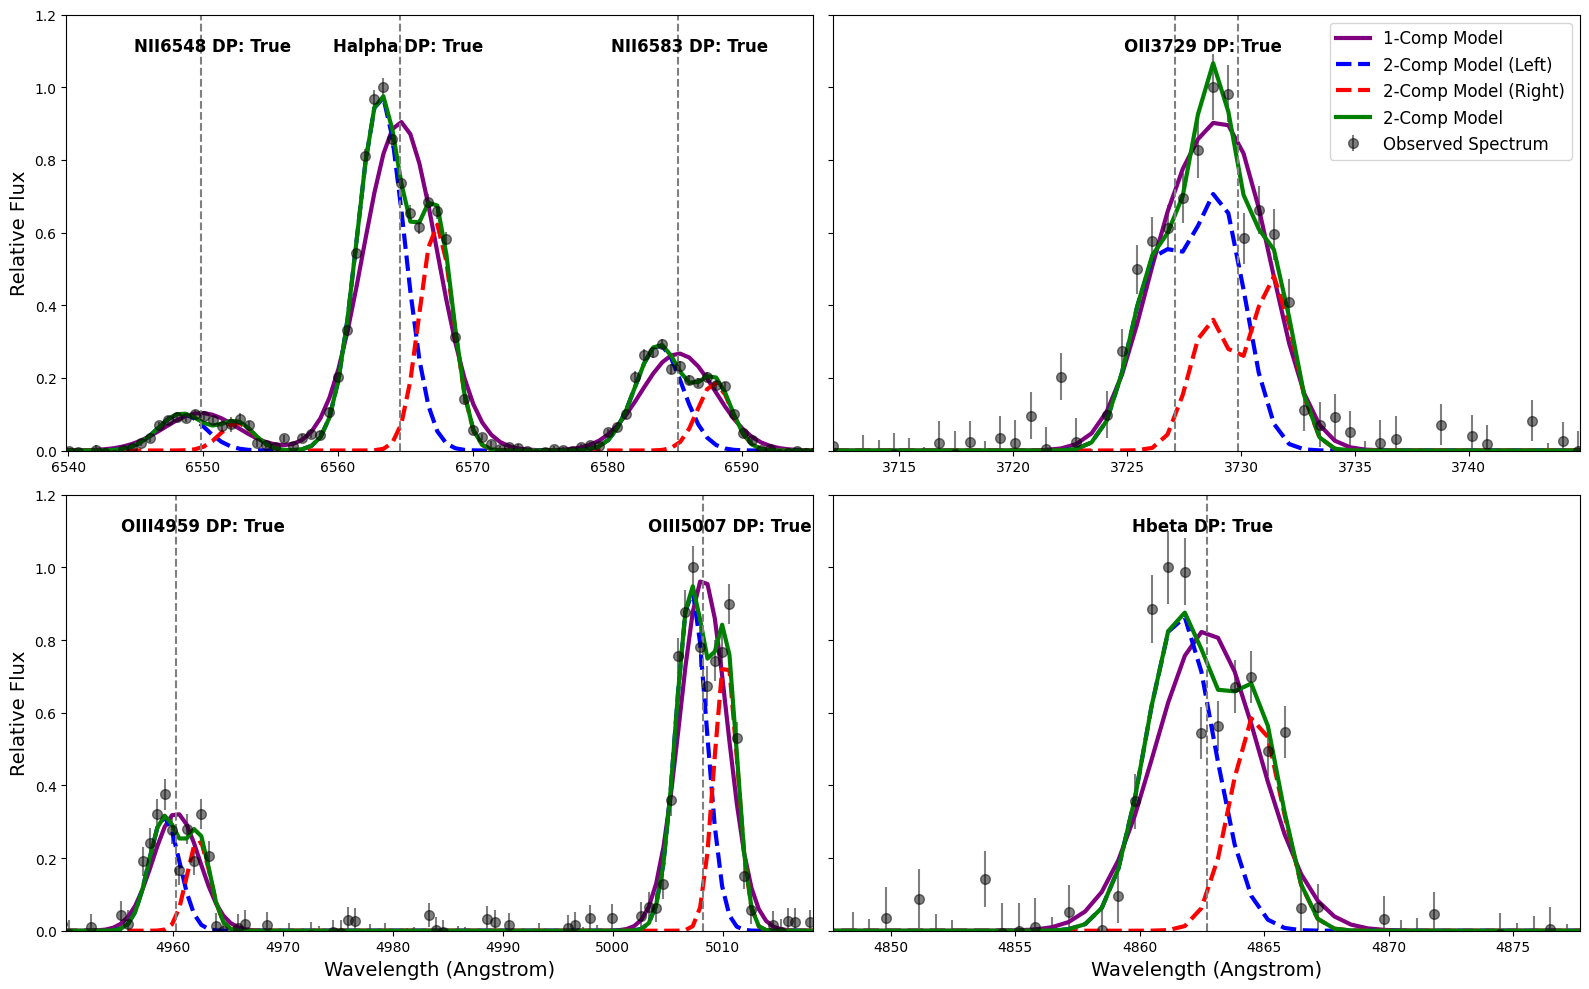

In [115]:
line_cols = ['OII3726', 'OII3729',
            'Hbeta',
            'OIII4959', 'OIII5007',
            'NII6548', 'Halpha', 'NII6583',
            'SII6716', 'SII6731']
lines = [*OII_rest, *Hbeta_rest, *OIII_rest, NII_rest[0], *Halpha_rest, NII_rest[1], *SII_rest]

# plt.figure(figsize=(12,6))

fig, axes = plt.subplots(2, 2, figsize=(16,10), sharey=True)
plt.subplots_adjust(wspace=-0.8)
axes = axes.flatten()

for i, ax in enumerate(axes):

    
    # plt.plot(lam, emission, label='Emission Line Only', color='orange', alpha=0.7)
    # plt.plot(lam, 3*sigma, label=r'3$\sigma$ Limit', color='red', linestyle='--')
    # plt.text(6550, 10, 'test', rotation=90, color='gray', fontsize=8)
    # ax.set_xlabel('Wavelength (Angstrom)')
    # ax.set_ylabel('Flux')
    if i == 0:
        ax.set_xlim([NII_rest[0]-10, NII_rest[1]+10])
        ax.set_ylabel('Relative Flux', fontsize=14)
    elif i == 1:
        ax.set_xlim([OII_rest[0]-15, OII_rest[1]+15])
    elif i == 2:
        ax.set_xlim([OIII_rest[0]-10, OIII_rest[1]+10])
        ax.set_xlabel('Wavelength (Angstrom)', fontsize=14)
        ax.set_ylabel('Relative Flux', fontsize=14)
    elif i == 3:
        ax.set_xlim([Hbeta_rest[0]-15, Hbeta_rest[0]+15])
        ax.set_xlabel('Wavelength (Angstrom)', fontsize=14)

    v_max = np.max(flux[(lam>ax.get_xlim()[0]) & (lam<ax.get_xlim()[1])])
    ax.set_ylim(bottom=0, top=1.2)

    ax.errorbar(lam, flux/v_max, yerr=sigma/v_max, label='Observed Spectrum', fmt='o', color='k', markersize=7, alpha=0.5)
    ax.plot(lam, test_1comp/v_max, label='1-Comp Model', linewidth=3, color='purple')
    ax.plot(lam, test_2comp_l/v_max, label='2-Comp Model (Left)', linestyle='--', linewidth=3, color='blue')
    ax.plot(lam, test_2comp_r/v_max, label='2-Comp Model (Right)', linestyle='--', linewidth=3, color='red')
    ax.plot(lam, test_2comp/v_max, label='2-Comp Model', linewidth=3, color='green')

    
    for i, line in enumerate(lines):

        if line < ax.get_xlim()[0] or line > ax.get_xlim()[1]:
            continue
        else:
            ax.axvline(x=line, color='gray', linestyle='--')
            if i != 0:
                line_label = f'{line_cols[i]} DP: {example_df[line_cols[i]+'_dp']}'
                if i != 2:
                    ax.text(line-5, 1.1, line_label, color='k', fontsize=12, weight='bold')
                else:
                    ax.text(line-3, 1.1, line_label, color='k', fontsize=12, weight='bold')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.savefig('./figures/Jan22/spectrum.png')
plt.show()
